In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import root_mean_squared_error , accuracy_score

In [9]:
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [10]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
df.shape

(569, 31)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0],test_size=0.2, random_state=2)

In [13]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
560,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,0.06171,0.3645,1.4920,2.888,29.840,0.007256,0.026780,0.020710,0.016260,0.02080,0.005304,15.30,33.17,100.20,706.7,0.1241,0.22640,0.1326,0.10480,0.2250,0.08321
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,0.1415,0.9671,0.968,9.704,0.005883,0.006263,0.009398,0.006189,0.02009,0.002377,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
198,19.18,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.06772,0.1767,0.05529,0.4357,1.0730,3.833,54.220,0.005524,0.036980,0.027060,0.012210,0.01415,0.003397,23.36,32.06,166.40,1688.0,0.1322,0.56010,0.3865,0.17080,0.3193,0.09221
203,13.81,23.75,91.56,597.8,0.13230,0.17680,0.15580,0.09176,0.2251,0.07421,0.5648,1.9300,3.909,52.720,0.008824,0.031080,0.031120,0.012910,0.01998,0.004506,19.20,41.85,128.50,1153.0,0.2226,0.52090,0.4646,0.20130,0.4432,0.10860
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,0.2366,1.4280,1.822,16.970,0.008064,0.017640,0.025950,0.010370,0.01357,0.003040,12.84,35.34,87.22,514.0,0.1909,0.26980,0.4023,0.14240,0.2964,0.09606


In [14]:
X_train.shape
columns = X_train.columns.to_list()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train) , columns = columns)
X_test = pd.DataFrame(scaler.transform(X_test) , columns = columns)

In [16]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-0.013303,1.775766,-0.014920,-0.144789,0.228790,0.175467,-0.544402,-0.128256,-1.012054,-0.152706,-0.118093,0.515657,0.035246,-0.205720,0.090435,0.087759,-0.391625,0.792650,0.038697,0.649487,-0.186400,1.187213,-0.196141,-0.291354,-0.332182,-0.171367,-0.659330,-0.132370,-1.080145,-0.035279
1,-0.844828,-0.628428,-0.877027,-0.765610,-1.019821,-1.249059,-0.944554,-0.889091,-1.109505,-0.186165,-0.916501,-0.454229,-0.903633,-0.637863,-0.364288,-1.078731,-0.824486,-0.928587,-0.049898,-0.568631,-0.949992,-0.884569,-0.980765,-0.806497,-1.240630,-1.224541,-1.078200,-1.115526,-0.857740,-0.720989
2,1.447559,0.711802,1.474288,1.405424,-0.758582,0.754792,0.319555,0.511737,-0.149990,-1.086665,0.136825,-0.258552,0.497350,0.317505,-0.483186,0.667678,-0.148638,0.100464,-0.791107,-0.144142,1.513753,1.008666,1.813225,1.478636,0.016558,1.968844,0.565914,0.875840,0.496760,0.463217
3,-0.081648,0.999483,-0.007498,-0.152149,2.546938,1.407012,0.893973,1.135134,1.664093,1.665752,0.599043,1.324974,0.534514,0.285313,0.609741,0.332235,0.006720,0.220101,-0.063625,0.317387,0.636255,2.583414,0.662848,0.513646,3.908676,1.717432,0.942800,1.341755,2.568643,1.371035
4,-0.896086,0.451519,-0.818069,-0.793920,1.872772,0.351950,0.228993,0.225711,0.329767,0.864176,-0.576014,0.397401,-0.486028,-0.481926,0.358037,-0.431894,-0.191113,-0.214011,-0.863481,-0.292713,-0.705305,1.536263,-0.590122,-0.638931,2.543851,0.106982,0.642160,0.442004,0.113821,0.676463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,-1.021384,0.848793,-1.026278,-0.898381,0.383989,-0.680668,-0.798879,-0.758136,-0.419854,0.407379,-0.396283,-0.129209,-0.257665,-0.404880,1.055522,-0.614398,-0.471983,0.150028,1.765687,-0.737595,-1.108195,-0.252418,-1.109765,-0.911834,-0.754115,-1.070936,-1.098564,-1.255912,-1.118606,-0.890478
451,-0.893238,-0.400109,-0.863834,-0.809490,0.058844,-0.113812,-0.440773,-0.521380,-0.704710,0.192074,-0.883563,0.683803,-0.807300,-0.629579,0.833956,0.485743,0.499964,0.314101,-0.907154,-0.087127,-0.962648,0.115934,-0.917630,-0.831027,0.472935,-0.013593,-0.274722,-0.226927,-1.014929,-0.059096
452,-0.466085,-1.493755,-0.532349,-0.493276,-1.566878,-1.208967,-1.028867,-0.946400,-0.727198,-0.382559,-0.250206,0.504571,-0.346174,-0.318177,1.128384,-0.864559,-0.938594,-0.637014,1.023231,0.448479,-0.631477,-1.516720,-0.710927,-0.602857,-1.611328,-1.207994,-1.218434,-1.323890,-1.029979,-0.751453
453,-0.500258,-1.621613,-0.527814,-0.518188,-0.421499,-0.774665,-0.738979,-0.557944,-0.442342,-0.680786,-1.005651,-1.325260,-0.999770,-0.653937,-1.093569,-0.913511,-0.849970,-1.005325,-1.147985,-0.989375,-0.542883,-1.048639,-0.590122,-0.547122,-0.112605,-0.293225,-0.434935,-0.098763,0.357966,-0.439062


In [17]:
X_train.shape

(455, 30)

In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

In [25]:
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [26]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))
accuracy_score(y_train , knn.predict(X_train))

0.9912280701754386


0.9802197802197802

In [28]:
test_scores = []
train_scores = []

for i in range(1,16):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    
    knn.fit(X_train,y_train)
    
    y_pred = knn.predict(X_test)

    test_scores.append(accuracy_score(y_test, y_pred))
    train_scores.append(accuracy_score(y_train , knn.predict(X_train)))
    

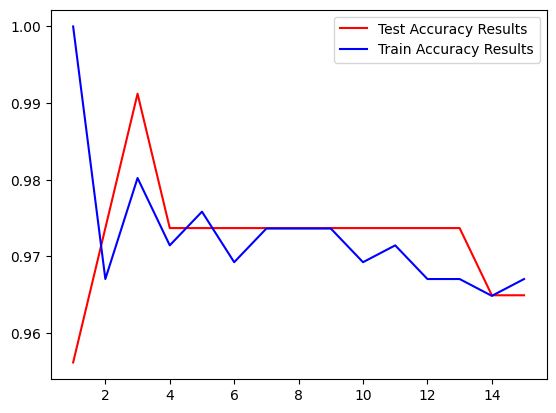

In [30]:
import matplotlib.pyplot as plt

plt.plot(range(1,16),test_scores ,color='red', label = 'Test Accuracy Results')
plt.plot(range(1,16),train_scores ,color='blue', label ='Train Accuracy Results')
plt.legend()
plt.show()

### ***Applying Cross-Validation (More Accurate Results)***

Best K value -> 14
Best Cross Validation Accuracy -> 0.935010091600683


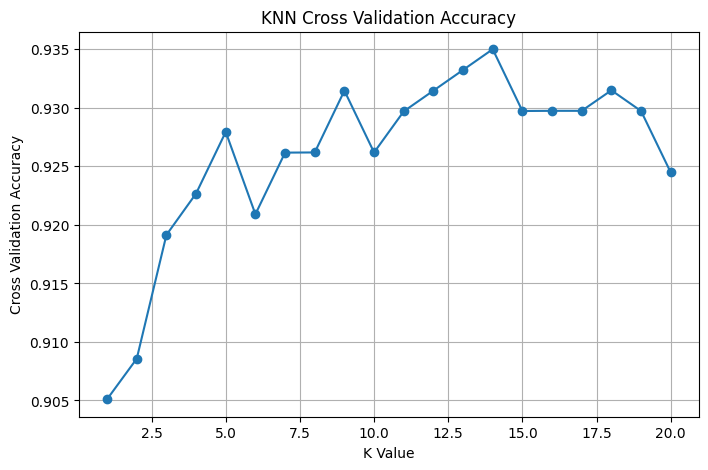

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Store mean cross-validation accuracies
cv_scores = []

# Try different K values
k_values = range(1, 21)

for k in k_values:
    
    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Perform 5-Fold Cross Validation
    scores = cross_val_score(
        knn,
        df.iloc[:,1:],              # Features
        df.iloc[:,0],              # Target
        cv=5,           # Number of folds
        scoring='accuracy'
    )
    
    # Store mean accuracy
    cv_scores.append(scores.mean()) 

# Best K
best_k = k_values[np.argmax(cv_scores)]

print(f"Best K value -> {best_k}")
print(f"Best Cross Validation Accuracy -> {max(cv_scores)}")

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("Cross Validation Accuracy")
plt.title("KNN Cross Validation Accuracy")

plt.grid(True)
plt.show()

### ***Making Decision Surface***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()

cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y));


interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

### ***Using Mlxtend Class To Plot Decision Surfaces***

c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


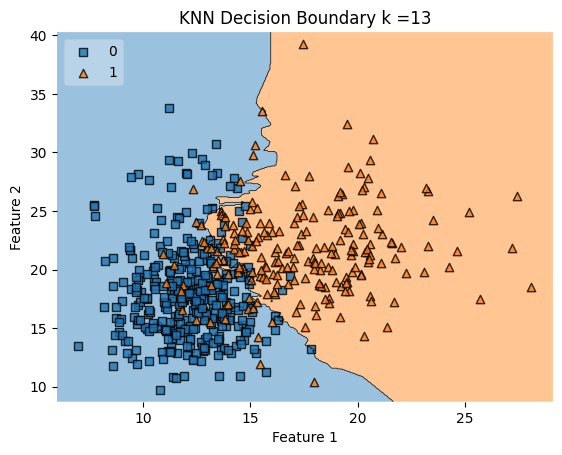

In [44]:
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Features (only 2 columns)
X = df.iloc[:,1:3]

# Target
y = df.iloc[:,0]

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train model
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X, y_encoded)

# Plot decision boundary
plot_decision_regions(
    np.array(X),
    y_encoded,
    clf=knn,
    legend=2
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KNN Decision Boundary k =13')

plt.show()